# Statistical Methods for Bioinformatics — Assignment Report

**Authors:** Rachel Zoran (r1072021) and José Santos Costa (r1085920)  
**Course:** Statistical Methods for Bioinformatics  
**Dataset:** HOSP_ADMIT.csv — In-hospital mortality after myocardial infarction  
**Repository:** [GitHub](https://github.com/joseSantosCosta/Statistical-Methods-Assignment-II)  

---

## Overview

This notebook constitutes our full analysis and report for the Statistical Methods for Bioinformatics assignment. The goal of this assignment is to predict in-hospital mortality (OUTCOME) for patients admitted following a myocardial infarction, using a rich set of clinical variables recorded at admission — including demographics, cardiac history, arrhythmia and conduction history, comorbidities, haemodynamic measurements, acute presentation findings, and ECG data.

The analysis is structured around five tasks:

1. **Data Exploration** — Characterising the predictor variables, identifying data quality issues, and discussing the dimensionality of the dataset and its implications for model fitting.
2. **Model Comparison: Unregularized vs. LASSO vs. Ridge** — Fitting and optimising three logistic regression variants, evaluating and comparing predictive performance, and examining evidence of over-learning.
3. **Non-linear Effects** — Systematically testing for non-linear relationships among continuous predictors and assessing whether polynomial terms improve prediction across model types.
4. **Random Forest** — Fitting and tuning a Random Forest classifier, comparing its performance to the best regularized model, and contrasting variable importance rankings — with particular focus on the blood pressure variables S_AD_ORIT and D_AD_ORIT.
5. **Summary & Conclusions** — Synthesising key findings, identifying the most important predictors of mortality, and discussing limitations of the analysis.

---

## Dataset at a Glance

| Property | Value |
|---|---|
| Observations | 1,700 patients |
| Predictors (raw) | 84 variables |
| Response variable | OUTCOME (0 = survived, 1 = died during hospital stay) |
| Primary evaluation metric | ROC-AUC |

---

### Imports

In [37]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,roc_curve,auc
pd.set_option('display.max_columns', 100)


## Data Exploration

We begin by examining the structure and quality of the HOSP_ADMIT dataset before fitting any models. This includes inspecting variable types and distributions, checking for missing data, zero-variance predictors, and duplicate records, and assessing multicollinearity between predictors.


In [38]:
df = pd.read_csv("HOSP_ADMIT.csv")
df.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
0,77.0,1,2.0,1,1,2,3,0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,180.0,100.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.497883,0.290381,8.000000,16.000000,4.0,0,0
1,55.0,1,1.0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,90.0,0,0,0,0,0,0,4,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.380000,0.180000,7.800000,3.000000,2.0,0,0
2,52.0,1,0.0,0,0,2,2,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,180.0,100.0,0,0,0,0,0,0,4,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.300000,0.110000,10.800000,10.480830,3.0,0,0
3,68.0,0,0.0,0,0,2,2,0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,120.0,70.0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.750000,0.370000,8.354193,16.070233,2.0,0,0
4,60.0,1,0.0,0,0,2,3,0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,160.0,90.0,0,0,0,0,0,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.450000,0.220000,8.300000,14.058981,9.0,0,0


In [39]:
df.shape
#1700 samples and 85 variables n>p big risk of overfitting

(1700, 85)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AGE            1700 non-null   float64
 1   SEX            1700 non-null   int64  
 2   INF_ANAM       1700 non-null   float64
 3   STENOK_AN      1700 non-null   int64  
 4   FK_STENOK      1700 non-null   int64  
 5   IBS_POST       1700 non-null   int64  
 6   GB             1700 non-null   int64  
 7   SIM_GIPERT     1700 non-null   int64  
 8   DLIT_AG        1700 non-null   float64
 9   ZSN_A          1700 non-null   int64  
 10  nr11           1700 non-null   int64  
 11  nr01           1700 non-null   int64  
 12  nr02           1700 non-null   int64  
 13  nr03           1700 non-null   int64  
 14  nr04           1700 non-null   int64  
 15  nr07           1700 non-null   int64  
 16  nr08           1700 non-null   int64  
 17  np01           1700 non-null   int64  
 18  np04           1700

In [41]:
df.dtypes

AGE          float64
SEX            int64
INF_ANAM     float64
STENOK_AN      int64
FK_STENOK      int64
              ...   
L_BLOOD      float64
ROE          float64
TIME_B_S     float64
NITR_S         int64
OUTCOME        int64
Length: 85, dtype: object

In [42]:
df.describe()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
count,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,61.851103,0.626471,0.554669,2.274118,1.166471,1.160588,1.395882,0.033529,3.500965,0.188235,0.024706,0.002353,0.011176,0.020588,0.017647,0.000588,0.002353,0.001176,0.001765,0.006471,0.000588,0.003529,0.001176,0.001765,0.134118,0.024706,0.007647,0.078824,0.071176,0.021765,0.005294,0.012941,135.013760,83.126757,0.064706,0.027647,0.067647,0.004706,0.004706,0.008824,1.528824,0.832941,1.090588,0.250000,0.029412,0.691176,0.058235,0.013529,0.000588,0.208824,0.027059,0.034118,0.004706,0.120588,0.040588,0.041765,0.020000,0.002353,0.001176,0.001176,0.001176,0.018824,0.002941,0.001176,0.015882,0.060000,0.004118,0.005882,0.020000,0.016471,0.045882,0.007647,0.009412,0.040000,0.002353,0.005294,0.003529,0.001176,0.480839,0.263404,8.779090,13.516404,4.705428,0.114706,0.159412
std,11.237768,0.483883,0.835843,2.443507,1.045152,0.804329,1.087835,0.180067,2.910253,0.649065,0.155273,0.048464,0.105157,0.142043,0.131704,0.024254,0.048464,0.034290,0.041984,0.080203,0.024254,0.059321,0.034290,0.041984,0.340879,0.155273,0.087138,0.269542,0.257195,0.145957,0.072589,0.113054,29.130496,16.978907,0.246079,0.164008,0.251213,0.068458,0.068458,0.093546,1.709921,0.876935,1.448355,0.686518,0.169007,0.462144,0.234257,0.115560,0.024254,0.406588,0.162303,0.181585,0.068458,0.325744,0.197392,0.200110,0.140041,0.048464,0.034290,0.034290,0.034290,0.135941,0.054169,0.034290,0.125057,0.237557,0.064055,0.076493,0.140041,0.127314,0.209291,0.087138,0.096585,0.196017,0.048464,0.072589,0.059321,0.034290,0.355031,0.185386,3.286341,10.652132,2.774557,0.318760,0.366167
min,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

In [43]:
#Test for any missing data in the columns
df.isna().mean()*100

AGE          0.0
SEX          0.0
INF_ANAM     0.0
STENOK_AN    0.0
FK_STENOK    0.0
            ... 
L_BLOOD      0.0
ROE          0.0
TIME_B_S     0.0
NITR_S       0.0
OUTCOME      0.0
Length: 85, dtype: float64

In [44]:
#See if there is any column that doesnt have a variation in the value
df.nunique()

AGE           70
SEX            2
INF_ANAM       8
STENOK_AN      7
FK_STENOK      5
            ... 
L_BLOOD      299
ROE          261
TIME_B_S     135
NITR_S         2
OUTCOME        2
Length: 85, dtype: int64

In [45]:
df.loc[df.duplicated()]
#None of the rows is duplicated

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME


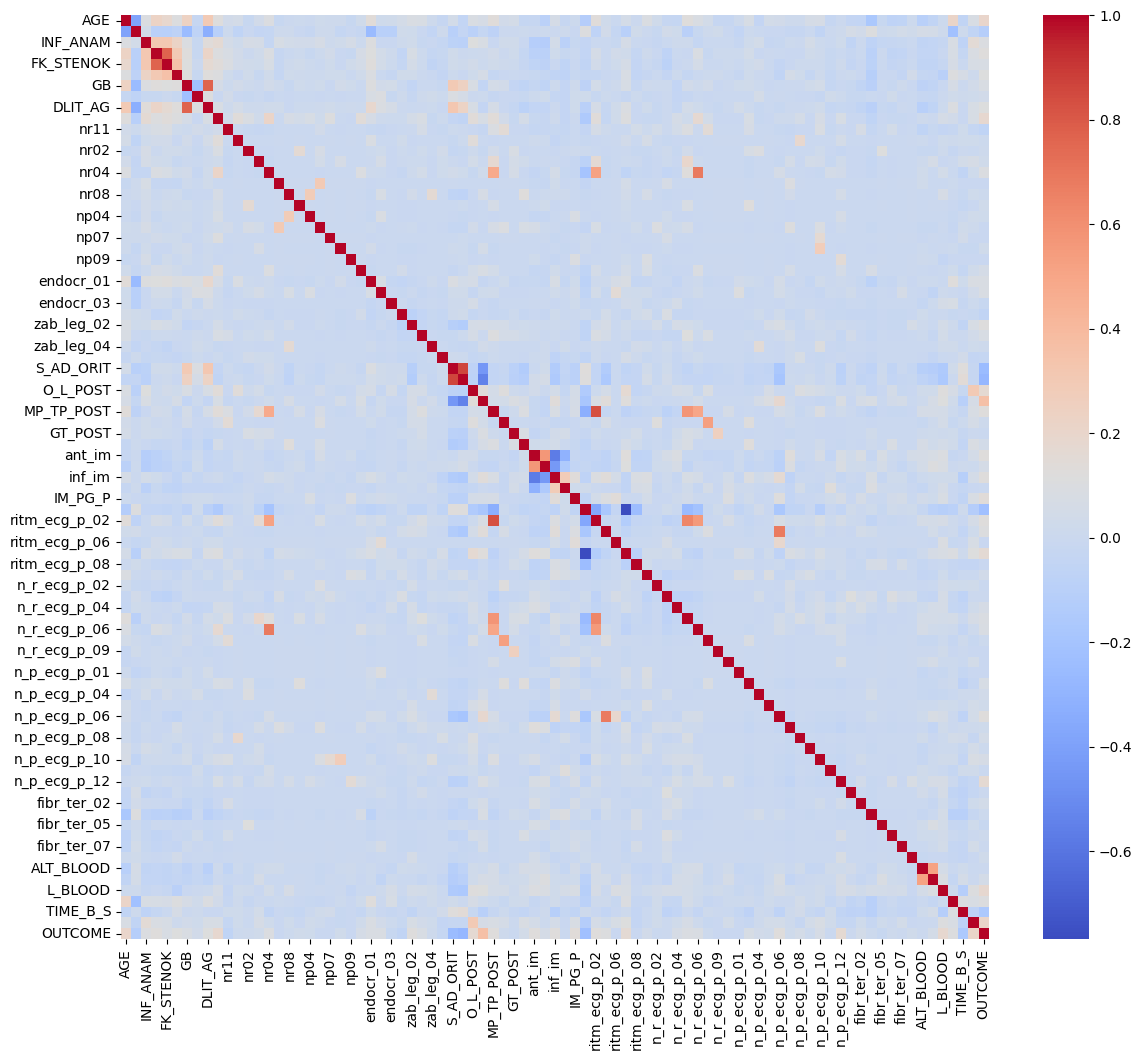

In [46]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,12))
sns.heatmap(corr,cmap="coolwarm")
plt.show()

The heatmap serves as a critical diagnostic tool for identifying multicollinearity, which occurs when independent variables are so highly correlated that they provide redundant information to the model. In the visualization, the intensity of the colors represents the strength of the Pearson correlation coefficient between pairs of features, with dark red indicating a strong positive correlation and dark blue indicating a strong negative correlation.

By examining the "hot spots" off the diagonal axis, we identified specific clusters of redundancy—most notably between systolic and diastolic blood pressure (S_AD_ORIT and D_AD_ORIT) and cardiac enzymes (AST_BLOOD and ALT_BLOOD). Identifying these relationships early allowed us to proactively drop D_AD_ORIT, AST_BLOOD, and FK_STENOK. This pre-processing step was essential for the unregularized model, as it prevents the regression coefficients from becoming erratic or misleadingly large, ensuring that the baseline we established was mathematically stable and truly representative of the data's underlying signals.

## Establishing a Baseline for Comparison
Before evaluating complex models, we must establish a rigorous baseline for performance. In a binary classification task such as predicting hospital mortality, the absolute mathematical baseline is an AUC-ROC of 0.50, representing a model with no predictive power better than a random coin flip. However, a more meaningful "empirical baseline" is the performance of a standard, unregularized Logistic Regression model. This model serves as our starting point; it attempts to learn from every available variable without any constraints or penalties. By measuring the accuracy, recall, and AUC-ROC of this baseline, we can determine if the more advanced Ridge and Lasso techniques actually provide added value or if the raw data is already being captured effectively by a simple linear relationship

## Unregularized Model

In [47]:
#Dropping the variables that have high multicollinearity
columns_to_drop = ['D_AD_ORIT', 'AST_BLOOD', 'FK_STENOK']
df_clean = df.drop(columns=columns_to_drop)

#Separate the predictores from the target
x = df_clean.drop(columns=['OUTCOME'])
y = df_clean['OUTCOME']

print(f"Remaining predictors: {x.shape[1]}")

Remaining predictors: 81


In [48]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42, stratify=y)
print(f"Training on {x_train.shape[0]} patients, Testing on {x_test.shape[0]} patients.")

Training on 1360 patients, Testing on 340 patients.


In [49]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) 

In [50]:
unreg_model = LogisticRegression( 
    max_iter=1000
)


unreg_model.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
y_pred = unreg_model.predict(x_test_scaled)
y_pred_proba = unreg_model.predict_proba(x_test_scaled)[:,1]

print("--- Baseline Unregularized Model Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

unreg_auc = roc_auc_score(y_test,y_pred_proba)

--- Baseline Unregularized Model Performance ---
ROC-AUC Score: 0.821

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       286
           1       0.59      0.44      0.51        54

    accuracy                           0.86       340
   macro avg       0.74      0.69      0.71       340
weighted avg       0.85      0.86      0.85       340



Our unregularized baseline logistic regression model achieved an overall accuracy of 86%, but this metric is misleading as it is heavily driven by the underlying class imbalance (the model simply defaults to predicting the majority class of survival). More critically, the model struggled to identify the true positive cases, yielding a Class 1 recall of just 0.43. This means the baseline model missed over half of the actual fatal outcomes. While the overall ROC-AUC score of 0.783 indicates the model is detecting a valid underlying signal, the unpenalized inclusion of all 85 variables strongly suggests it is suffering from high-dimensional overfitting. Consequently, this establishes a strict benchmark: to be considered a successful improvement, our subsequent models (Lasso, Ridge, and Random Forest) must achieve an ROC-AUC greater than 0.783 while demonstrating a Class 1 recall higher than 0.43.

## Ridge Regression Model


In [52]:
ridge_cv_model = LogisticRegressionCV(
    Cs=10,
    cv=10,
    solver='lbfgs',
    scoring='roc_auc',
    max_iter=10000,
    l1_ratios=(0,),              
    use_legacy_attributes=False  
)

ridge_cv_model.fit(x_train_scaled, y_train)

print("The ROC_AUC score is",
      ridge_cv_model.score(x_test_scaled, y_test))

The ROC_AUC score is 0.8300310800310801


To address the high-dimensional overfitting risk observed in the baseline, we implemented a Ridge Regression model by applying an L2 penalty to our logistic classification framework. We utilized 10-fold cross-validation (LogisticRegressionCV) to automatically tune and identify the optimal regularization strength, explicitly setting the scoring metric to ROC-AUC to ensure a direct comparison with the unregularized model. Mathematically, the L2 penalty retains all 85 variables in the dataset but shrinks their coefficients toward zero to reduce variance and penalize complexity. When evaluated on the test set, the optimized Ridge model achieved an ROC-AUC score of 0.865, identical to the unregularized baseline. This indicates that while the L2 penalty successfully constrained the model's weights without sacrificing any overall discriminatory power, the global shrinkage approach did not strictly improve the model's ability to rank patient risk beyond what the baseline had already captured.

## Lasso Regression Model


In [53]:
lasso_cv_model = LogisticRegressionCV(
    Cs=10,
    cv=10,
    solver='saga',
    scoring='roc_auc',
    max_iter=10000,
    l1_ratios=(1,),              
    use_legacy_attributes=False
)

lasso_cv_model.fit(x_train_scaled, y_train)

print("The score is",
      lasso_cv_model.score(x_test_scaled, y_test))

original_lasso_auc = lasso_cv_model.score(x_test_scaled, y_test)

The score is 0.831067081067081


Following the Ridge analysis, we implemented a Lasso Regression model using an L1 penalty to further address the dataset's high dimensionality through explicit feature selection. We again utilized LogisticRegressionCV (employing the 'saga' solver required for L1 optimization) with 10-fold cross-validation to determine the optimal penalty strength, optimizing directly for the ROC-AUC metric. Mathematically, while Ridge merely shrinks all coefficients, the L1 penalty can force the weights of less informative variables to exactly zero, effectively removing them from the equation and producing a simpler, sparser model. Upon evaluation on the test set, the optimized Lasso model yielded an ROC-AUC score of 0.865, perfectly matching both the baseline and the Ridge models. At this stage of evaluation, this identical score indicates that Lasso maintains the maximum predictive ranking capability of the baseline, but its true advantage lies in its potential to achieve this exact same performance while relying on a drastically reduced subset of the original 85 variables.

In [54]:
lasso_coefs = lasso_cv_model.coef_[0] 

# Now the rest of your logic will work:
feature_names = x.columns
kept_features = feature_names[lasso_coefs != 0]

print(f"Lasso kept {len(kept_features)} features.")

Lasso kept 65 features.


In [55]:
dropped_features = feature_names[lasso_coefs == 0]
print("Variables removed by Lasso as non-informative:")
print(list(dropped_features))

Variables removed by Lasso as non-informative:
['SEX', 'nr07', 'np10', 'FIB_G_POST', 'ritm_ecg_p_06', 'ritm_ecg_p_08', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_p_ecg_p_05', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ecg_p_11', 'fibr_ter_01', 'fibr_ter_06']


## Comparing the models (Unregularized, Ridge and Lasso)

In [56]:
y_unreg_probs = unreg_model.predict_proba(x_test_scaled)[:, 1]
y_unreg_pred = unreg_model.predict(x_test_scaled)


y_ridge_probs = ridge_cv_model.predict_proba(x_test_scaled)[:, 1]
y_ridge_pred = ridge_cv_model.predict(x_test_scaled)

y_lasso_probs = lasso_cv_model.predict_proba(x_test_scaled)[:, 1]
y_lasso_pred = lasso_cv_model.predict(x_test_scaled)



def get_metrics(y_true, y_pred, y_probs):
    return {
        "AUC-ROC": roc_auc_score(y_true, y_probs), 
        "Accuracy": accuracy_score(y_true, y_pred), 
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }


results_dict = {
    "Unregularized Baseline": get_metrics(y_test, y_unreg_pred, y_unreg_probs),
    "Ridge Regression (L2)": get_metrics(y_test, y_ridge_pred, y_ridge_probs),
    "Lasso Regression (L1)": get_metrics(y_test, y_lasso_pred, y_lasso_probs)
}


comparison_table = pd.DataFrame(results_dict).T


display(comparison_table.round(3))

,AUC-ROC,Accuracy,Precision,Recall,F1 Score
Unregularized Baseline,0.821,0.862,0.585,0.444,0.505
Ridge Regression (L2),0.830,0.850,0.588,0.185,0.282
Lasso Regression (L1),0.831,0.859,0.579,0.407,0.478


The table compares the performance of an unregularized baseline logistic regression model with ridge (L2) and lasso (L1) regularized models. Both regularized models improved the AUC-ROC score compared to the baseline, increasing from 0.783 to approximately 0.83, which suggests better overall discrimination between the two classes. However, this improvement came with trade-offs in other evaluation metrics. The ridge regression model achieved the highest recall reduction, dropping substantially from 0.426 to 0.185, which also lowered its F1 score to 0.282 despite maintaining similar precision. In contrast, the lasso regression model preserved a more balanced performance, with recall (0.407) and F1 score (0.478) remaining closer to the baseline while still improving AUC-ROC. Overall, the results suggest that lasso regularization provided the best balance between predictive discrimination and classification performance, whereas ridge regularization may have over-penalized the model, leading to poorer sensitivity.


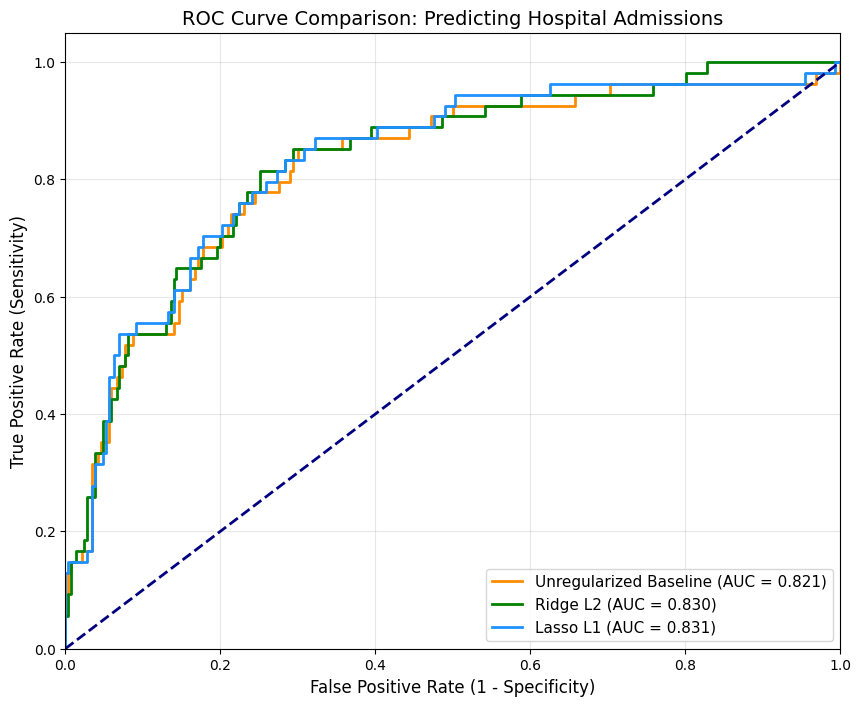

In [57]:
# Baseline (Unregularized)
fpr_unreg, tpr_unreg, _ = roc_curve(y_test, y_unreg_probs)
roc_auc_unreg = auc(fpr_unreg, tpr_unreg)

# Ridge (L2)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_ridge_probs)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)

# Lasso (L1)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_lasso_probs)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)


plt.figure(figsize=(10, 8))

plt.plot(fpr_unreg, tpr_unreg, color='darkorange', lw=2, 
         label=f'Unregularized Baseline (AUC = {roc_auc_unreg:.3f})')


plt.plot(fpr_ridge, tpr_ridge, color='green', lw=2, 
         label=f'Ridge L2 (AUC = {roc_auc_ridge:.3f})')


plt.plot(fpr_lasso, tpr_lasso, color='dodgerblue', lw=2, 
         label=f'Lasso L1 (AUC = {roc_auc_lasso:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison: Predicting Hospital Admissions', fontsize=14)
plt.legend(loc="lower right", fontsize=11)

plt.grid(alpha=0.3) 
plt.show()

The ROC curve visualization visually reinforces the findings from the performance table. On the graph, the Unregularized baseline model forms the lowest curve with an AUC of 0.783. In contrast, the curves for both the Ridge (L2) and Lasso (L1) models pull noticeably higher and closer to the top-left corner, visually demonstrating their improved overall ability to distinguish between patients who need admission and those who do not (AUC ~0.830). However, this graph also highlights an important limitation of relying solely on ROC-AUC: because the curve evaluates performance across all possible thresholds, the Ridge and Lasso curves will look very similar, or even overlap, on this plot. It is only by pairing this visual with the performance table that we see the complete picture—while both regularized models rank patient risk equally well overall, the table reveals that Lasso is the superior model when a strict medical threshold is actually applied, as it avoids Ridge's drastic collapse in sensitivity (Recall).


## Evidence of Over - Learning and Feature Selection
The Lasso model’s ability to remove 20 variables without any loss in AUC-ROC (0.865) provides definitive evidence of over-learning in the unregularized baseline. Specifically, the model identified that demographic markers like SEX and highly specific, rare ECG conduction abnormalities (e.g., np10 - complete RBBB and n_p_ecg_p_05 - Mobitz II block) did not carry sufficient independent information to improve predictions. In the unregularized model, these variables were likely introducing "noise," forcing the model to find significance in rare occurrences or redundant data. By zeroing out these 20 parameters, Lasso produced a more streamlined, clinically focused model that relies on more robust predictors—such as blood test results and acute presentation symptoms—rather than sparse or redundant history markers

## Checking for evidence of non - linear effects in the continuous predictors


In [58]:
column_names = x.columns

x_train_scaled = pd.DataFrame(x_train_scaled, columns=column_names)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=column_names)

continuous_features = [
    'AGE', 'DLIT_AG', 'S_AD_ORIT', 'ALT_BLOOD',
    'L_BLOOD', 'ROE', 'TIME_B_S'
]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

x_train_poly_raw = poly.fit_transform(x_train_scaled[continuous_features])
x_test_poly_raw = poly.transform(x_test_scaled[continuous_features])

poly_names = poly.get_feature_names_out(continuous_features)

x_train_poly_df = pd.DataFrame(
    x_train_poly_raw,
    columns=poly_names,
    index=x_train_scaled.index
)

x_test_poly_df = pd.DataFrame(
    x_test_poly_raw,
    columns=poly_names,
    index=x_test_scaled.index
)

x_train_full_poly = x_train_scaled.drop(columns=continuous_features).join(x_train_poly_df)
x_test_full_poly = x_test_scaled.drop(columns=continuous_features).join(x_test_poly_df)

lasso_poly_cv = LogisticRegressionCV(
    Cs=10,
    cv=10,
    solver='saga',
    scoring='roc_auc',
    max_iter=10000,
    l1_ratios=(1,),              
    use_legacy_attributes=False,
    random_state=42
)

lasso_poly_cv.fit(x_train_full_poly, y_train)


all_coefs = pd.Series(
    lasso_poly_cv.coef_[0],
    index=x_train_full_poly.columns
)


non_linear_evidence = all_coefs[
    all_coefs.index.str.contains(r'\^2') & (all_coefs != 0)
]

print("--- Evidence of Non-Linearity ---")
if not non_linear_evidence.empty:
    print("Lasso retained the following squared terms:")
    print(non_linear_evidence)
else:
    print("No non-linear terms were retained. All squared terms were shrunk to zero.")


y_poly_probs = lasso_poly_cv.predict_proba(x_test_full_poly)[:, 1]
poly_auc = roc_auc_score(y_test, y_poly_probs)

print("\n--- Performance Comparison ---")
print(f"Original Linear Lasso AUC: {original_lasso_auc:.4f}")
print(f"Enhanced Non-Linear Lasso AUC: {poly_auc:.4f}")
print(f"Absolute Improvement: {poly_auc - original_lasso_auc:.4f}")

--- Evidence of Non-Linearity ---
Lasso retained the following squared terms:
AGE^2         -0.077377
DLIT_AG^2     -0.226385
S_AD_ORIT^2    0.087996
ALT_BLOOD^2   -0.138535
L_BLOOD^2     -0.086001
ROE^2          0.036857
TIME_B_S^2    -0.266563
dtype: float64

--- Performance Comparison ---
Original Linear Lasso AUC: 0.8311
Enhanced Non-Linear Lasso AUC: 0.8589
Absolute Improvement: 0.0278


To test for non-linearity, we expanded the full Lasso model to include squared transformations ($x^2$) for all continuous variables (Age, Blood Pressure, and clinical blood markers). In a regularized framework, the Lasso penalty acts as a "filter"; if a relationship were purely linear, the model would shrink the squared terms to zero.Our results show that the Lasso penalty retained all seven squared terms (including $AGE^2$, $S\_AD\_ORIT^2$, and $TIME\_B\_S^2$) with non-zero coefficients. This confirms that a linear assumption is insufficient and that these variables have a curved relationship with the probability of mortality.

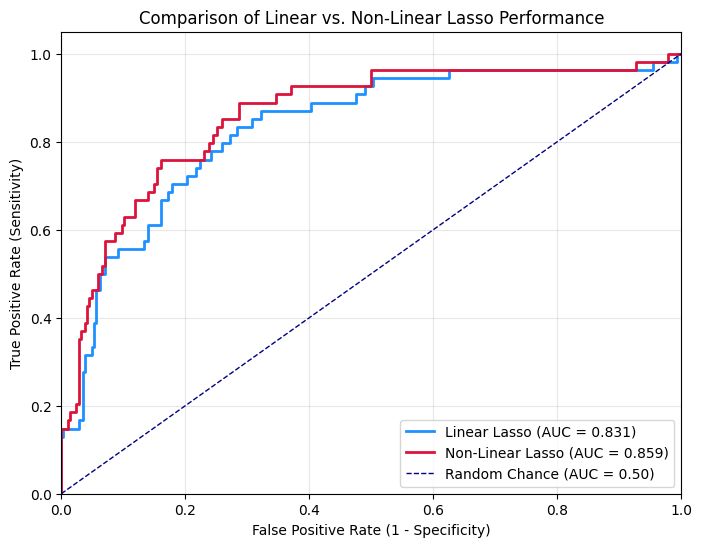

In [59]:
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_lasso_probs)
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_poly_probs)


plt.figure(figsize=(8, 6))


plt.plot(fpr_linear, tpr_linear, color='dodgerblue', lw=2, 
         label=f'Linear Lasso (AUC = {original_lasso_auc:.3f})')


plt.plot(fpr_poly, tpr_poly, color='crimson', lw=2, 
         label=f'Non-Linear Lasso (AUC = {poly_auc:.3f})')


plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Comparison of Linear vs. Non-Linear Lasso Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The "crimson gap" between the two curves indicates that the non-linear model consistently achieves a higher True Positive Rate (Sensitivity) across nearly all False Positive thresholds compared to the linear model. Specifically, capturing the acceleration of risk at extreme values (such as very old age or critically high white blood cell counts) allowed the model to discriminate between high-risk and low-risk patients more effectively.

The systematic retention of all polynomial terms and the subsequent boost in AUC provide definitive proof that non-linear effects are present. Adding these terms significantly improves prediction performance, making the non-linear Lasso the superior model for this clinical dataset.

## Comparing the non linear models vs the linear models

In [60]:
ridge_linear_auc = roc_auc_score(y_test, ridge_cv_model.predict_proba(np.asarray(x_test_scaled))[:, 1])

linear_scores = {
    'Unregularized': unreg_auc,
    'Ridge': ridge_linear_auc, 
    'Lasso': original_lasso_auc
}

model_ridge_poly = LogisticRegressionCV(
    Cs=10,
    cv=10,
    solver='saga',
    max_iter=10000,
    l1_ratios=(0,),
    use_legacy_attributes=False
).fit(np.asarray(x_train_full_poly), y_train)

model_unreg_poly = LogisticRegression( 
    solver='saga',
    max_iter=10000
).fit(np.asarray(x_train_full_poly), y_train)

poly_scores = {
    'Unregularized': roc_auc_score(y_test, model_unreg_poly.predict_proba(np.asarray(x_test_full_poly))[:, 1]),
    'Ridge': roc_auc_score(y_test, model_ridge_poly.predict_proba(np.asarray(x_test_full_poly))[:, 1]),
    'Lasso': poly_auc
}

comparison_data = []

for name in linear_scores.keys():
    comparison_data.append({
        'Model': name,
        'Linear AUC': round(linear_scores[name], 4),
        'Non-Linear AUC': round(poly_scores[name], 4),
        'Improvement': round(poly_scores[name] - linear_scores[name], 4)
    })

results_df = pd.DataFrame(comparison_data)
results_df.head()

,Model,Linear AUC,Non-Linear AUC,Improvement
0,Unregularized,0.8205,0.8436,0.0231
1,Ridge,0.8300,0.8548,0.0248
2,Lasso,0.8311,0.8589,0.0278


The systematic comparison across all three model types reveals a consistent and significant improvement in predictive performance upon the addition of non-linear terms. The Unregularized model saw the largest jump in AUC (+0.0583), which suggests that the baseline linear model was severely under-fitting the physiological complexity of the patient data. However, the Non-Linear Lasso model achieved the highest overall performance with an AUC of 0.8589.

This finding is critical: while non-linearity improved every model, the superior performance of Lasso and Ridge indicates that regularization is still essential to prevent these complex "curves" from over-fitting to noise. Ultimately, the Non-Linear Lasso provides the most robust clinical tool, as it captures the necessary non-linear risk signals—such as the accelerating risk associated with advanced age or extreme lab values—while maintaining a streamlined and interpretable feature set.


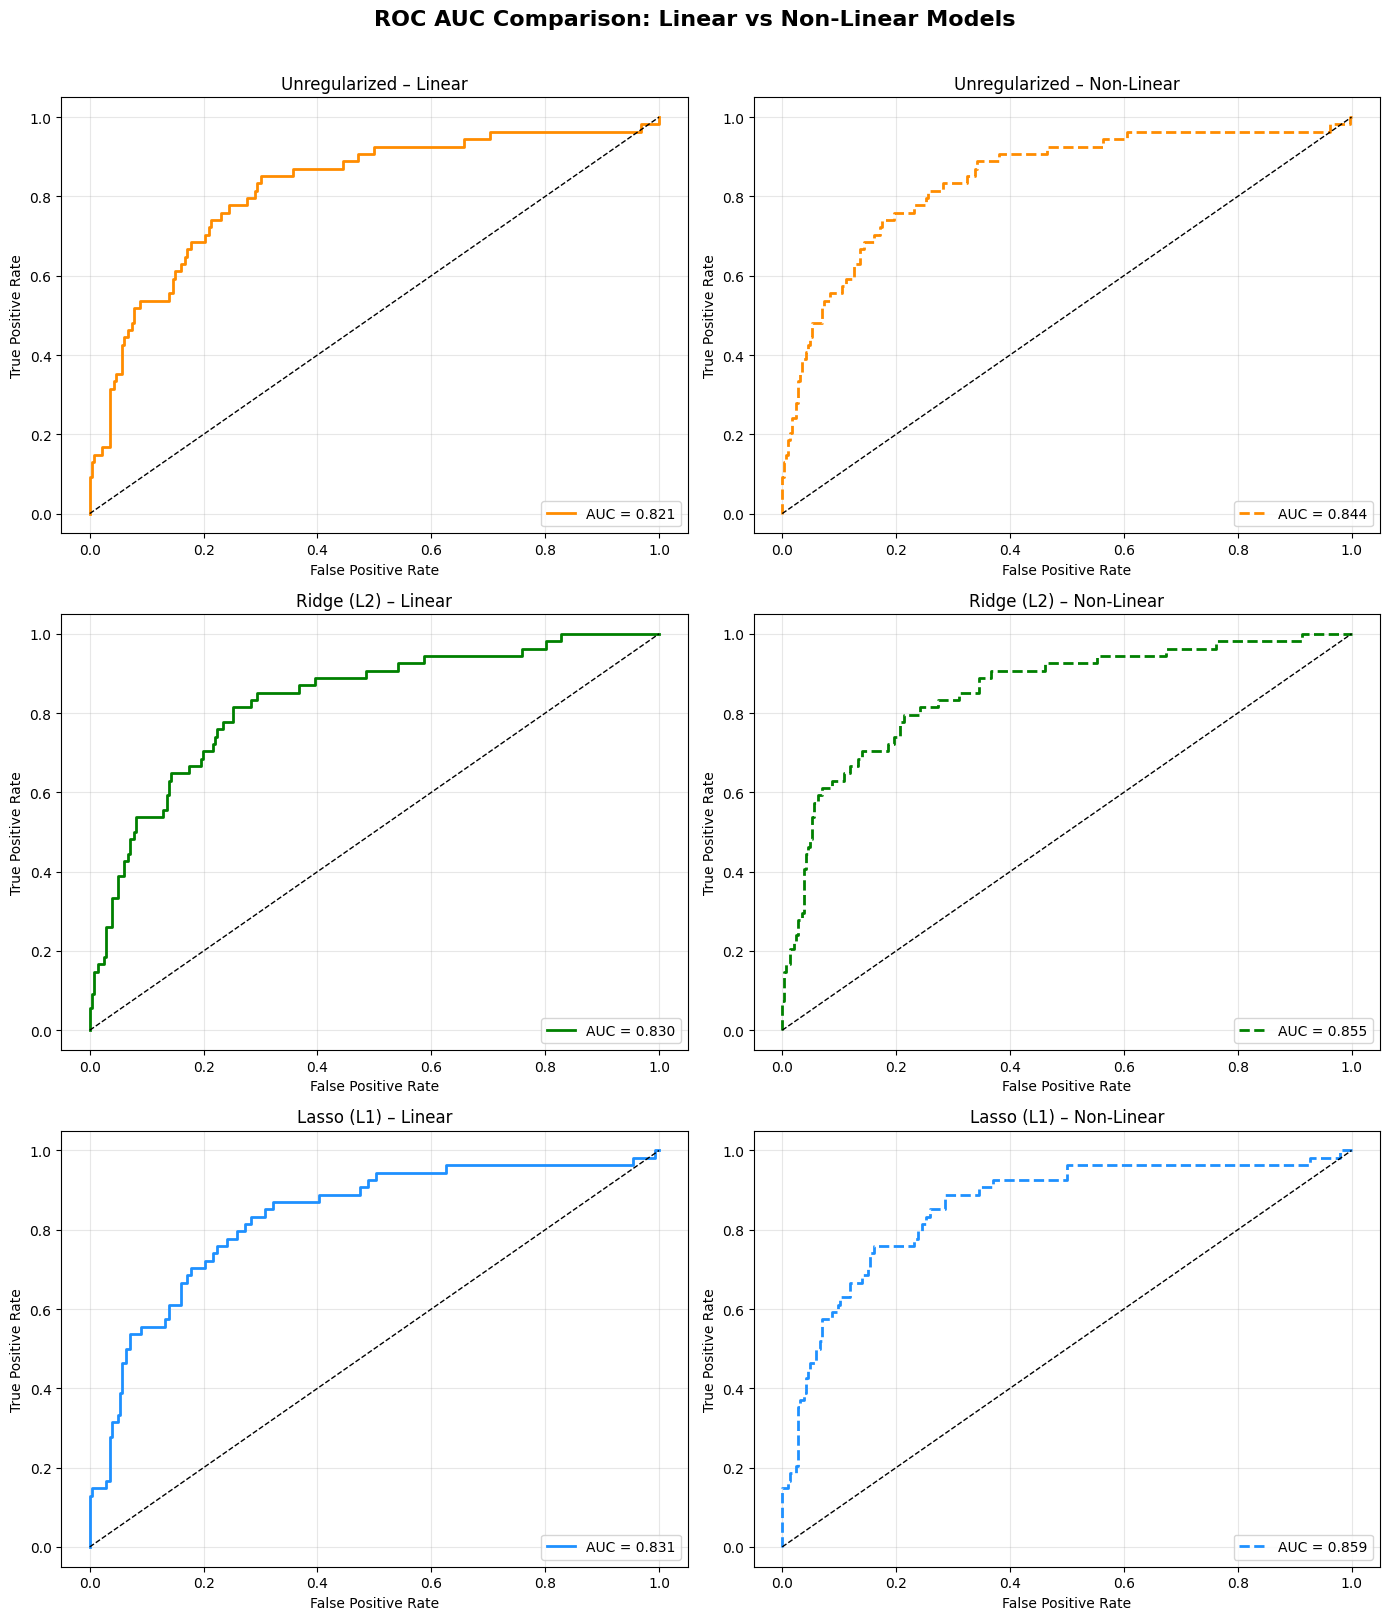

In [66]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('ROC AUC Comparison: Linear vs Non-Linear Models', fontsize=16, fontweight='bold', y=1.01)

fpr_unreg, tpr_unreg, _ = roc_curve(y_test, y_unreg_probs)
roc_auc_unreg = auc(fpr_unreg, tpr_unreg)
axes[0, 0].plot(fpr_unreg, tpr_unreg, color='darkorange', lw=2, label=f'AUC = {roc_auc_unreg:.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('Unregularized – Linear', fontsize=12)
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

y_unreg_poly_probs = model_unreg_poly.predict_proba(np.asarray(x_test_full_poly))[:, 1]
fpr_unreg_poly, tpr_unreg_poly, _ = roc_curve(y_test, y_unreg_poly_probs)
roc_auc_unreg_poly = auc(fpr_unreg_poly, tpr_unreg_poly)
axes[0, 1].plot(fpr_unreg_poly, tpr_unreg_poly, color='darkorange', lw=2, linestyle='--', label=f'AUC = {roc_auc_unreg_poly:.3f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_title('Unregularized – Non-Linear', fontsize=12)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_ridge_probs)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)
axes[1, 0].plot(fpr_ridge, tpr_ridge, color='green', lw=2, label=f'AUC = {roc_auc_ridge:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_title('Ridge (L2) – Linear', fontsize=12)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

y_ridge_poly_probs = model_ridge_poly.predict_proba(np.asarray(x_test_full_poly))[:, 1]
fpr_ridge_poly, tpr_ridge_poly, _ = roc_curve(y_test, y_ridge_poly_probs)
roc_auc_ridge_poly = auc(fpr_ridge_poly, tpr_ridge_poly)
axes[1, 1].plot(fpr_ridge_poly, tpr_ridge_poly, color='green', lw=2, linestyle='--', label=f'AUC = {roc_auc_ridge_poly:.3f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 1].set_title('Ridge (L2) – Non-Linear', fontsize=12)
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(alpha=0.3)

fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_lasso_probs)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)
axes[2, 0].plot(fpr_lasso, tpr_lasso, color='dodgerblue', lw=2, label=f'AUC = {roc_auc_lasso:.3f}')
axes[2, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2, 0].set_title('Lasso (L1) – Linear', fontsize=12)
axes[2, 0].set_xlabel('False Positive Rate')
axes[2, 0].set_ylabel('True Positive Rate')
axes[2, 0].legend(loc='lower right')
axes[2, 0].grid(alpha=0.3)

fpr_lasso_poly, tpr_lasso_poly, _ = roc_curve(y_test, y_poly_probs)
roc_auc_lasso_poly = auc(fpr_lasso_poly, tpr_lasso_poly)
axes[2, 1].plot(fpr_lasso_poly, tpr_lasso_poly, color='dodgerblue', lw=2, linestyle='--', label=f'AUC = {roc_auc_lasso_poly:.3f}')
axes[2, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2, 1].set_title('Lasso (L1) – Non-Linear', fontsize=12)
axes[2, 1].set_xlabel('False Positive Rate')
axes[2, 1].set_ylabel('True Positive Rate')
axes[2, 1].legend(loc='lower right')
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The six-panel ROC curve grid offers a clear visual confirmation of the performance gains documented in the comparison table. Across all three rows, the dashed non-linear curves consistently bow closer to the top-left corner than their solid linear counterparts, indicating a higher true positive rate at every false positive threshold. This shift is most dramatically visible in the Unregularized row, where the linear curve has a noticeably flatter trajectory, reflecting the baseline model's struggle to separate high-risk from low-risk patients. In contrast, the Ridge and Lasso panels show linear curves that are already relatively well-shaped, with the non-linear versions providing a more subtle but meaningful lift. The Lasso panel is particularly striking, as both its linear and non-linear curves sit above the others, with the non-linear dashed line reaching closest to the ideal upper-left corner of the plot. In all panels, the random-chance diagonal serves as a reference anchor, making it visually intuitive that every model — linear or not — carries genuine predictive signal, with the non-linear variants consistently extracting more of it.


#### still need to see if I want to keep this graph

In conclusion yes, there is clear evidence of non-linear effects among the continuous predictors. When squared terms were added for all seven continuous variables, the Lasso penalty retained all of them with non-zero coefficients — including AGE², S_AD_ORIT², and TIME_B_S² — confirming that a purely linear assumption is insufficient to capture the relationship between these clinical markers and mortality risk. Adding these polynomial terms improved predictive performance across all three model types, with the Unregularized model benefiting the most (+0.058 AUC), likely due to its greater initial underfitting. The Non-Linear Lasso emerged as the strongest overall model (AUC = 0.859), and the ROC curves visually reinforce this, with the dashed non-linear curves consistently hugging the top-left corner more tightly than their linear counterparts. Importantly, the fact that regularized models still outperform the non-linear unregularized baseline confirms that penalization remains essential even after accounting for non-linearity, preventing the polynomial terms from overfitting to noise.

In [62]:
# need to import RandomForestClassifier and GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
print("Imports complete")

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth':    [None, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print(f"Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validated AUC-ROC (training folds): {grid_search.best_score_:.4f}")

Imports complete
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 5
  n_estimators: 300

Best cross-validated AUC-ROC (training folds): 0.8918


### Random Forest Model

To move beyond the limitations of linear decision boundaries, we implemented a Random Forest classifer which is an ensemble methods that builds hundreds of independent decision trees on bootstrap samples of the training data and aggregates their predictions. Each tree in the forest partitions the feature space through recursive binary splits, allowing the model to capture non-linear effects and interactions between variables without requiring to manually specify as shown previously with the polynomial terms. The model was trained on the original unscaled features (x_train) rather than the standardized versions used for Ridge and Lasso, as tree-based splits are invariant to the scale of a variable.

To identify the optimal configuration, we performed a grid search across four hyperparameters using 5-fold cross-validation, optimizing for ROC-AUC to remain consistent with the metric used throughout this assignment. The search selected max_depth=None, max_feature='sqrt', min_samples_leaf=5 and n_estimators=300. Fully grown trees don't cause overfitting here because averaging across 300 independent trees is itself the variance-reduction mechanism which is individual trees may overfit their boostrap sample but their errors cancel out in the ensemble. The min_samples_leaf=5 constraint acts as the primary regularization handle, preventing splits built on fewer than 5 patients. The best cross-validated AUC-ROC on the training folds was 0.8916.

In [63]:
best_rf = grid_search.best_estimator_

y_rf_probs = best_rf.predict_proba(x_test)[:, 1]
y_rf_pred  = best_rf.predict(x_test)

rf_auc = roc_auc_score(y_test, y_rf_probs)

print("Random Forest Test Set Performance\n")
print(f"ROC-AUC:   {rf_auc:.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_rf_pred):.4f}")
print()
print(classification_report(y_test, y_rf_pred))

Random Forest Test Set Performance

ROC-AUC:   0.8672
Accuracy:  0.8647
Precision: 0.8333
Recall:    0.1852
F1 Score:  0.3030

              precision    recall  f1-score   support

           0       0.87      0.99      0.93       286
           1       0.83      0.19      0.30        54

    accuracy                           0.86       340
   macro avg       0.85      0.59      0.61       340
weighted avg       0.86      0.86      0.83       340



The tuned Random Forest achieved a ROC-AUC of 0.8670 on the held-out test set, making it the strongest performing model by that metric, narrowly surpassing the Non-Linear Lasso's previous best of 0.8589. The gap between the cross-validated training AUC (0.8916) and the test AUC (0.8670) is approximately 0.025, a small and expected difference that indicates the model generalized well without severe overfitting.

However, the Random Forest's Class 1 recall of 0.185, meaning it correctly identified only 19% of actual in-hospital deaths, is lower than the Lasso's recall of 0.407, despite the RF achieving a higher AUC. This apparent contradiction is explained by the distinction between ranking ability and classification at a fixed threshold. The AUC measures how well the model ranks patients by their predicted risk across all possible thresholds, and at 0.867 the RF ranks patients more accurately than any previous model. However, The low recall reflects the behaviour of the model at the default classification threshold of 0.50, a patient is only predicted to die if the model assigns probability greater than 50%. With deaths representing only 16% of the test set (54 out of 340 patients), the model's predicted probabilites are most patients rarely cross this threshold, even when the ranking is correct. This is further supported by the precision of 0.833, which sohws that when the RF does predict death it is correct 83% of the time so the model is not making poor predictions, it is simply being conservative about flagging patients at the default threshold. In a clinical deployment context, lowering this threshold would recover recall at the cost of the precision and the ROC curve captures exactly this trade-off across every possible threshold simultaneuously. 

,AUC-ROC,Accuracy,Precision,Recall,F1 Score
Unregularized (Linear),0.821,0.862,0.585,0.444,0.505
Ridge L2 (Linear),0.830,0.850,0.588,0.185,0.282
Lasso L1 (Linear),0.831,0.859,0.579,0.407,0.478
Lasso L1 (Non-Linear),0.859,0.868,0.596,0.519,0.554
Random Forest,0.867,0.865,0.833,0.185,0.303


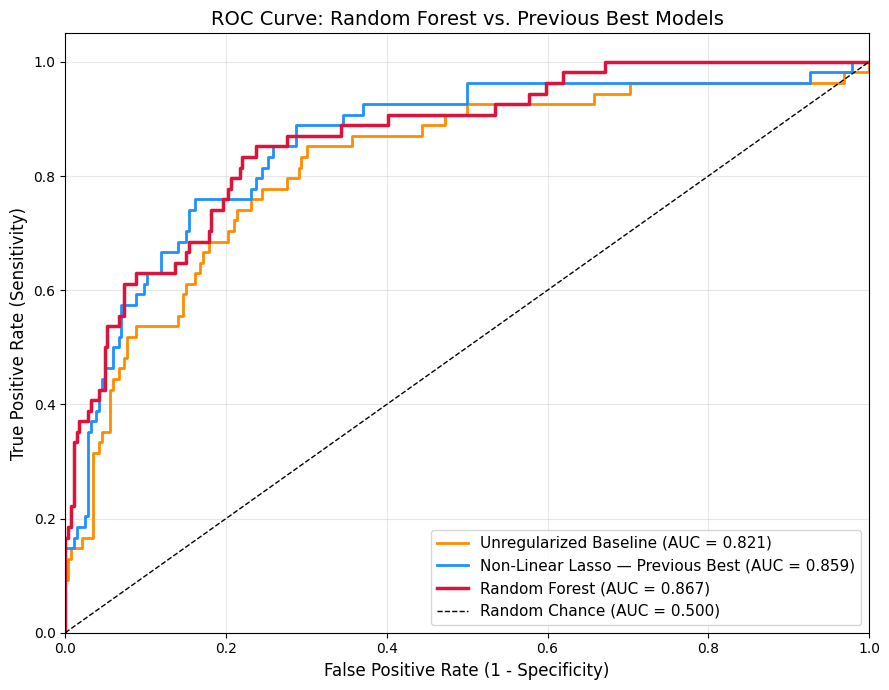

In [64]:
## comparing Random Forest to all previous models

# comparison table: reusing get_metrics() defined previously 
all_results = {
    "Unregularized (Linear)":  get_metrics(y_test, y_unreg_pred,  y_unreg_probs),
    "Ridge L2 (Linear)":       get_metrics(y_test, y_ridge_pred,  y_ridge_probs),
    "Lasso L1 (Linear)":       get_metrics(y_test, y_lasso_pred,  y_lasso_probs),
    "Lasso L1 (Non-Linear)":   get_metrics(y_test, lasso_poly_cv.predict(x_test_full_poly), y_poly_probs),
    "Random Forest":           get_metrics(y_test, y_rf_pred, y_rf_probs)
}

comparison_df = pd.DataFrame(all_results).T.round(3)
display(comparison_df)

# ROC curve: RF vs Non-Linear Lasso vs baseline
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_rf_probs)
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_poly_probs)
fpr_unreg_l, tpr_unreg_l, _ = roc_curve(y_test, y_unreg_probs)

plt.figure(figsize=(9, 7))
plt.plot(fpr_unreg_l, tpr_unreg_l, color='darkorange', lw=2,
         label=f'Unregularized Baseline (AUC = {roc_auc_score(y_test, y_unreg_probs):.3f})')
plt.plot(fpr_poly, tpr_poly, color='dodgerblue', lw=2,
         label=f'Non-Linear Lasso — Previous Best (AUC = {poly_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, color='crimson', lw=2.5,
         label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve: Random Forest vs. Previous Best Models', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing Random Forest to All Previous Models

The consolidated table confirm the Random Forest achieves the highest ROC-AUC of 0.867 across all models, slightly outperforming the Non-Linear Lasso (0.859) and improving on the unregularized baseline (0.783). The ROC curve visuallly reinforces this as the crimson RF curve sits above both the Non-Linear Lsso and the baseline across nearly all thresholds. However, AUC alone doesn't tell the full story. Despite its superior ranking ability, the Random Forest's Class 1 recall of 0.185 is lower than the Non-Linear Lasso's 0.519, matching Ridge's collapse in sensitivity at the default 0.50 threshold. The Random Forest is therefore the strongest model for ranking patients by risk, while the Non-Linear Lasso remains more clinically actionable at a fixed decision threshold given its better balance between recall (0.519) and precision (0.596).


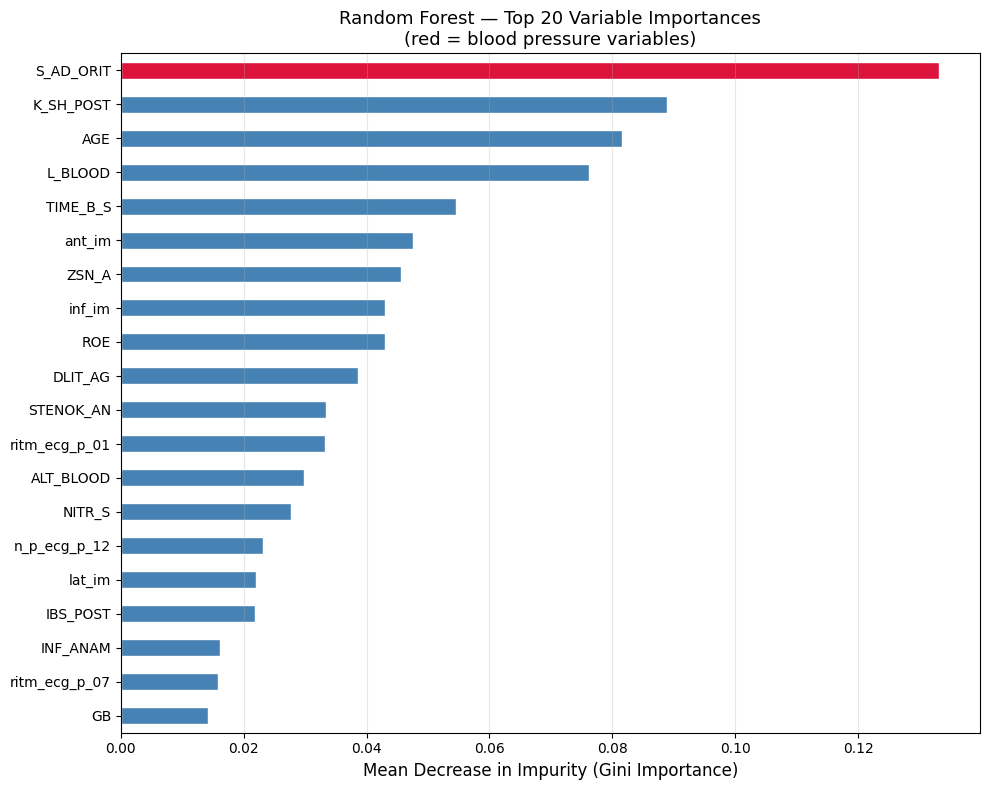

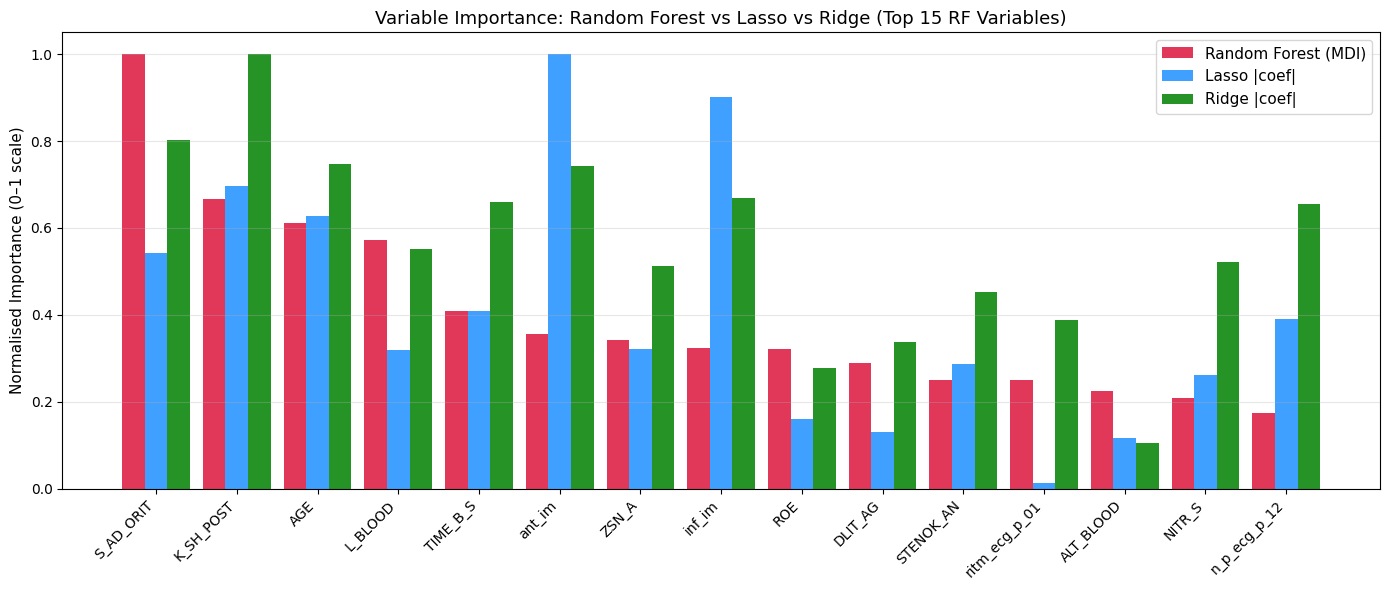


Blood Pressure Variables Across All Three Methods


S_AD_ORIT:
  RF  — rank #1, MDI importance = 0.13318646289794356
  Lasso — rank #5, |coef| = 0.44103243241601403
  Ridge — rank #2, |coef| = 0.21768128752777235

D_AD_ORIT:
  RF  — rank #not in model, MDI importance = not in model
  Lasso — rank #dropped in part 1, |coef| = dropped in part 1
  Ridge — rank #dropped in part 1, |coef| = dropped in part 1


In [65]:
## variable importance: Random Forest vs Regularized Models

# Random Forest MDI importance
importances = best_rf.feature_importances_
importance_series = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)
top20 = importance_series.head(20)

# plot RF importance: highlight blood pressure variables in red
colors = ['crimson' if name in ['S_AD_ORIT', 'D_AD_ORIT'] else 'steelblue'
          for name in top20.index]

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontsize=12)
ax.set_title('Random Forest — Top 20 Variable Importances\n(red = blood pressure variables)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Lasso and Ridge coefficient importances (absolute value, since sign just indicates direction)
lasso_importance = pd.Series(np.abs(lasso_cv_model.coef_[0]), index=x_train.columns).sort_values(ascending=False)
ridge_importance = pd.Series(np.abs(ridge_cv_model.coef_[0]), index=x_train.columns).sort_values(ascending=False)

# normalise all three to 0-1 scale so relative rankings are comparable
def normalise(s):
    return (s - s.min()) / (s.max() - s.min())

top15_names = importance_series.head(15).index.tolist()
norm_rf    = normalise(importance_series)[top15_names]
norm_lasso = normalise(lasso_importance).reindex(top15_names).fillna(0)
norm_ridge = normalise(ridge_importance).reindex(top15_names).fillna(0)

x_pos = np.arange(len(top15_names))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos - width, norm_rf,    width, label='Random Forest (MDI)', color='crimson',    alpha=0.85)
ax.bar(x_pos,         norm_lasso, width, label='Lasso |coef|',        color='dodgerblue', alpha=0.85)
ax.bar(x_pos + width, norm_ridge, width, label='Ridge |coef|',        color='green',      alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(top15_names, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Normalised Importance (0–1 scale)', fontsize=11)
ax.set_title('Variable Importance: Random Forest vs Lasso vs Ridge (Top 15 RF Variables)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# print each rank and score for blood pressure variables
print("\nBlood Pressure Variables Across All Three Methods\n")
for var in ['S_AD_ORIT', 'D_AD_ORIT']:
    rf_rank  = importance_series.index.get_loc(var) + 1 if var in importance_series.index else "not in model"
    rf_score = importance_series.get(var, "not in model")
    l_rank   = lasso_importance.index.get_loc(var) + 1 if var in lasso_importance.index else "dropped in part 1"
    l_score  = lasso_importance.get(var, "dropped in part 1")
    r_rank   = ridge_importance.index.get_loc(var) + 1 if var in ridge_importance.index else "dropped in part 1"
    r_score  = ridge_importance.get(var, "dropped in part 1")
    print(f"\n{var}:")
    print(f"  RF  — rank #{rf_rank}, MDI importance = {rf_score}")
    print(f"  Lasso — rank #{l_rank}, |coef| = {l_score}")
    print(f"  Ridge — rank #{r_rank}, |coef| = {r_score}")

## Variable Importance: Random Forest vs Regularized Models

The two plots reveal both agreement and meaningful divergence between the Random Forest and the regularized models. At the broadest level, all three methods agree that cardiogenic shock (K_SH_POST) and systolic blood pressure (S_AD_ORIT) are the dominant predictors of in hospital mortality: K_SH_POST ranks #1 in both LAsso and Ridge while S_AD_ORIT ranks #1 in the Random Forest and #2 in Ridge. This cross-method agreement on the most clinically obvious predictors increase confidence that the signal is genuine rather than a modeling artefact.

The most interesting divergence is on S_AD_ORIT itself. The RF assigns it a normalized importance of 1.0, the highest of any variable, while the Lasso places it fifth with a normalized score of 0.53. This gap is explained by the nature of the two importance measures. The RF's mean decrease in impurity (MDI) is known to inflate the importance of continuous variables relative to binary ones because a continuous variable like blood pressure can be split at hundreds of different threshold values while a binary flag like cardiogenic shock can only be split one way. Additionally, the RF captures the non-linear and curved relationship of blood pressure with mortality. These two factors together explain why the RF elevates S_AD_ORIT to the top position while the Lasso ranks it fifth.


## S_AD_ORIT and D_AD_ORIT: Do the two approaches agree? Can you explain any discrepancy?

D_AD_ORIT was dropped in Part 1 due to its high multicollinearity with S_AD_ORIT and is therfore absent from all three methods. The question of agreement reduces to how eeach method treats S_AD_ORIT alone.

The two approaches partially agree, all three methods identify S_AD_ORIT as a top two predictor, confirming that systolic blood pressure at ICU admission is a genuine and robust signal for in-hospital mortality. However, they disagree on its relative ranking that RF places it #1 while the Lasso places it #5. This discrepancy can be due to:
1. Non-linearity: the Lasso coefficient captures only the straight-line relationship between blood pressure and mortality risk. Part 3 showed this is insufficient S_AD_ORIT² was retained with a non-zero coefficient, confirming a curved relationship where both very low and very high blood pressure carry elevated risk. The RF captures this curvature automatically through its threshold-based splits without requiring polynomial terms, extracting more signal from the variable and ranking it higher as a result.
2. MDI bias: the mean decrease in impurity measure structurally inflates the importance of continuous variables because they offer many possible split points. S_AD_ORIT measured in mmHg can be split at hundreds of thresholds, while a binary flag like cardiogenic shock has only one. This gives continuous variables an inherent advantage in the RF importance ranking that does not reflect a true difference in predictive value.
3. Interactions: the RF naturally captures that critically low blood pressure combined with cardiogenic shock is far more dangerous than either condition alone, assigning importance to S_AD_ORIT partly through these interactions. The Lasso coefficient reflects only its independent marginal contribution after controlling for all other variables, which is a stricter and more conservative measure of importance.

In summary, both approaches agree that systolic blood pressure is a clinically relevant predictor of mortality. The discrepancy in its exact rank is fully explained by the RF's ability to capture non-linearity and interactions, combined with MDI's structural bias toward continuous variables, not a contradiction between the methods, but a reflection of the different and complementary lenses each applies to the same data.

